In [11]:
#!pip install shap
import shap

In [12]:
# pip install xgboost, catboost, lightgbm
import xgboost
import catboost
import lightgbm

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.impute import SimpleImputer, KNNImputer
from imblearn.pipeline import Pipeline
#from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.datasets import make_classification
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [14]:
mult_responses = pd.read_csv('data/bankruptcy_processed.csv')
df = mult_responses.copy()
df.head()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,operating gross margin,realized sales gross margin,operating profit rate,tax Pre-net interest rate,after-tax net interest rate,non-industry income and expenditure/revenue,continuous interest rate (after tax),...,total assets to GNP price,No-credit interval,Gross profit to Sales,Net income to stockholder's Equity,liability to equity,Degree of financial leverage (DFL),Interest coverage ratio( Interest expense to EBIT ),one if net income was negative for the last two year zero otherwise,equity to liability,Bankrupt?
0,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,0.780985,...,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1.0,0.016469,1
1,0.464291,0.538214,0.516730,NaN,0.610235,0.998946,0.797380,0.809301,0.303556,0.781506,...,0.008323,0.623652,0.610237,0.839969,NaN,0.264577,0.570175,1.0,0.020794,1
2,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,0.780284,...,0.040003,0.623841,NaN,0.836774,NaN,0.026555,0.563706,1.0,0.016474,1
3,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,0.781241,...,0.003252,NaN,0.583538,0.834697,0.281721,0.026697,0.564663,1.0,0.023982,1
4,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,NaN,0.809304,0.303475,0.781550,...,0.003878,NaN,0.598782,0.839973,NaN,0.024752,NaN,1.0,0.035490,1


In [5]:
# Check for nulls
#df.isnull().sum()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                               Non-Null Count  Dtype  
---  ------                                                               --------------  -----  
 0    ROA(C) before interest and depreciation before interest             6087 non-null   float64
 1    ROA(A) before interest and % after tax                              6161 non-null   float64
 2    ROA(B) before interest and depreciation after tax                   6153 non-null   float64
 3    operating gross margin                                              6125 non-null   float64
 4    realized sales gross margin                                         6128 non-null   float64
 5    operating profit rate                                               6128 non-null   float64
 6    tax Pre-net interest rate                                           6129 non-null   float64
 7    after

In [7]:
df.describe()

,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,operating gross margin,realized sales gross margin,operating profit rate,tax Pre-net interest rate,after-tax net interest rate,non-industry income and expenditure/revenue,continuous interest rate (after tax),...,total assets to GNP price,No-credit interval,Gross profit to Sales,Net income to stockholder's Equity,liability to equity,Degree of financial leverage (DFL),Interest coverage ratio( Interest expense to EBIT ),one if net income was negative for the last two year zero otherwise,equity to liability,Bankrupt?
count,6087.000000,6161.000000,6153.000000,6125.000000,6128.000000,6128.000000,6129.000000,6140.000000,6123.000000,6144.000000,...,6.116000e+03,6167.000000,6138.000000,6105.000000,6167.000000,6109.000000,6131.000000,6123.0,6135.000000,6819.000000
mean,0.505413,0.558618,0.553518,0.608066,0.607842,0.998898,0.797162,0.809169,0.303637,0.781350,...,1.955755e+07,0.623934,0.607773,0.840345,0.280317,0.027589,0.565359,1.0,0.047513,0.032263
std,0.060380,0.065572,0.061970,0.016431,0.017277,0.005036,0.013573,0.010946,0.011772,0.013340,...,3.860150e+08,0.012856,0.017298,0.015084,0.014348,0.016514,0.013903,0.0,0.050236,0.176710
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.612132,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
25%,0.476868,0.535488,0.527544,0.600448,0.600355,0.998969,0.797386,0.809311,0.303466,0.781567,...,9.068549e-04,0.623634,0.600351,0.840118,0.276926,0.026791,0.565158,1.0,0.024450,0.000000
50%,0.503047,0.559802,0.552278,0.606012,0.605904,0.999022,0.797465,0.809375,0.303525,0.781636,...,2.087324e-03,0.623881,0.605822,0.841177,0.278764,0.026808,0.565252,1.0,0.033728,0.000000
75%,0.535758,0.589294,0.583918,0.613925,0.613676,0.999094,0.797580,0.809468,0.303585,0.781735,...,5.304402e-03,0.624177,0.613671,0.842350,0.281460,0.026913,0.565725,1.0,0.052859,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000


In [8]:
len(df)

6819

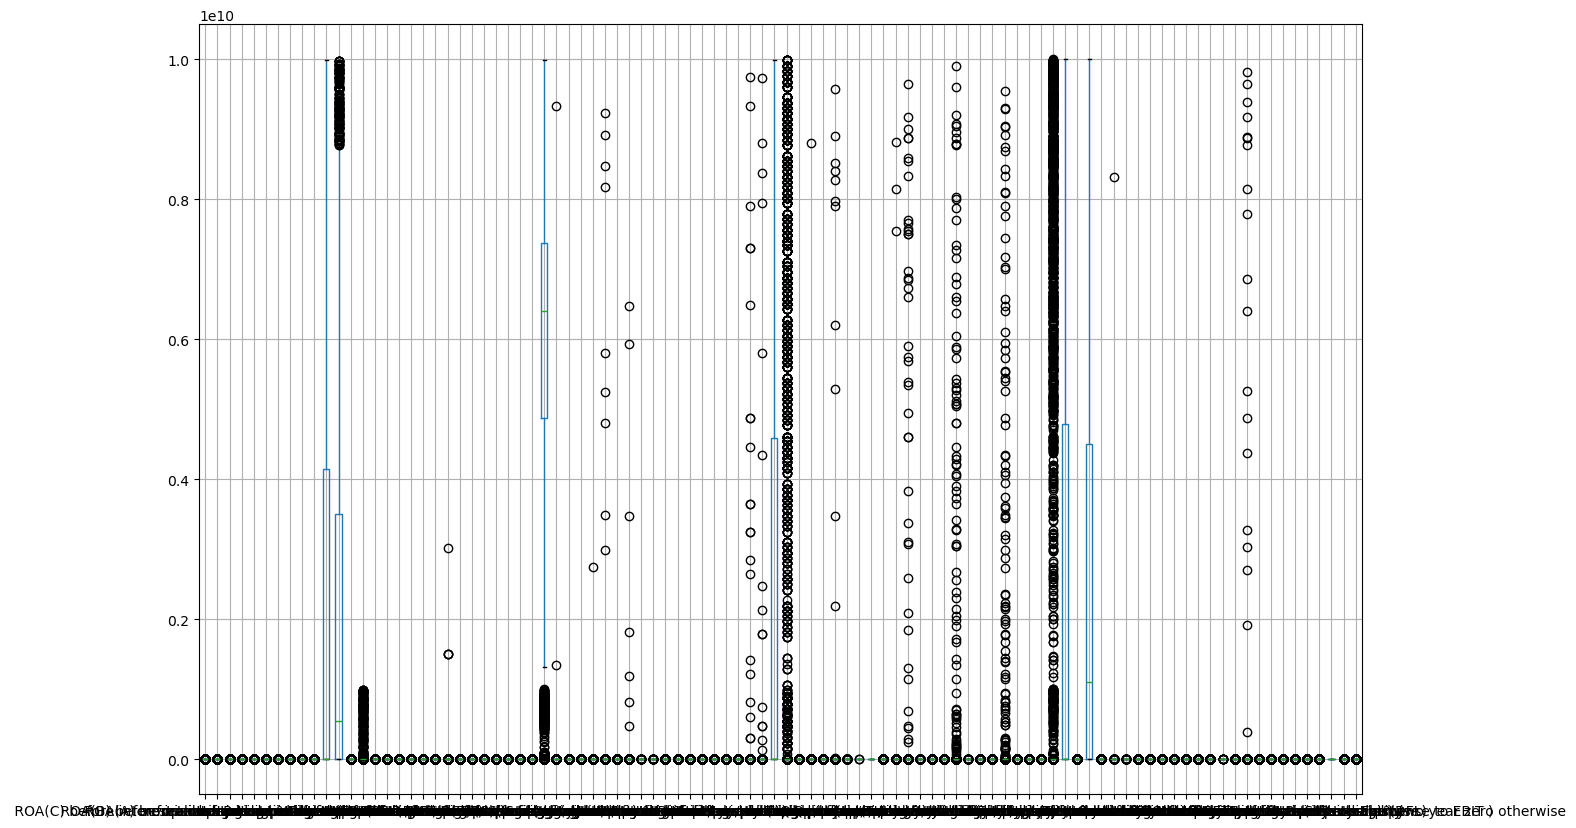

In [9]:
boxplot = df.boxplot(figsize=(15,10))

In [15]:
#sns.pairplot(df)

In [16]:
len(df)

6819

In [17]:
df.rename (columns={"Bankrupt?": "Bankrupt"}, inplace=True)

In [18]:
df1 = df.dropna()
len(df1)

0

In [19]:
df["Bankrupt"].value_counts()

0    6599
1     220
Name: Bankrupt, dtype: int64

In [20]:
df.isnull().sum()

 ROA(C) before interest and depreciation before interest               732
 ROA(A) before interest and % after tax                                658
 ROA(B) before interest and depreciation after tax                     666
 operating gross margin                                                694
 realized sales gross margin                                           691
                                                                      ... 
Degree of financial leverage (DFL)                                     710
Interest coverage ratio( Interest expense to EBIT )                    688
one if net income was negative for the last two year zero otherwise    696
equity to liability                                                    684
Bankrupt                                                                 0
Length: 96, dtype: int64

In [22]:
#Plot the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='Bankrupt', data=df)
plt.title('Class Distribution')
plt.show()

SyntaxError: incomplete input (1271977627.py, line 1)

In [ ]:
'''
#One hot encoding
#Drops NaNs
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
#OR
#keeps NaNs by adding an extra column
df_encoded = pd.get_dummies(df, dummy_na=True, dtype=int) # force get dummies to return 0-1 instead of True False, to resolve an issue in

In [24]:
df_corr = df.drop(['Bankrupt'], 1)
corr_matrix = df_corr.corr()
corr_matrix

C:\Users\aikat\AppData\Local\Temp\ipykernel_21320\2558820260.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df_corr = df.drop(['Bankrupt'], 1)


,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,operating gross margin,realized sales gross margin,operating profit rate,tax Pre-net interest rate,after-tax net interest rate,non-industry income and expenditure/revenue,continuous interest rate (after tax),...,net income to total assets,total assets to GNP price,No-credit interval,Gross profit to Sales,Net income to stockholder's Equity,liability to equity,Degree of financial leverage (DFL),Interest coverage ratio( Interest expense to EBIT ),one if net income was negative for the last two year zero otherwise,equity to liability
ROA(C) before interest and depreciation before interest,1.000000,0.936181,0.986416,0.337406,0.319801,0.067004,0.070733,0.056947,0.059010,0.068034,...,0.881529,-0.081003,0.007365,0.323914,0.264438,-0.137900,-0.017399,0.007264,NaN,0.047028
ROA(A) before interest and % after tax,0.936181,1.000000,0.955414,0.327992,0.309617,0.064726,0.054053,0.058547,0.027741,0.050116,...,0.959705,-0.109849,0.012479,0.314383,0.296483,-0.125919,-0.012588,0.009141,NaN,0.057778
ROA(B) before interest and depreciation after tax,0.986416,0.955414,1.000000,0.333856,0.332626,0.065055,0.053328,0.055882,0.018167,0.052735,...,0.908843,-0.100922,0.005707,0.336251,0.279496,-0.140768,-0.014643,0.011275,NaN,0.055990
operating gross margin,0.337406,0.327992,0.333856,1.000000,0.999500,0.012772,0.030807,0.036245,0.064532,0.014735,...,0.313846,0.022998,0.002200,1.000000,0.090049,-0.087699,-0.013857,0.003673,NaN,0.125291
realized sales gross margin,0.319801,0.309617,0.332626,0.999500,1.000000,0.023544,0.032153,0.036190,0.057566,0.013597,...,0.296109,0.027372,0.004386,0.999551,0.080219,-0.080645,-0.011933,0.005003,NaN,0.096005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
liability to equity,-0.137900,-0.125919,-0.140768,-0.087699,-0.080645,-0.004994,-0.003928,-0.009045,-0.018825,-0.002781,...,-0.129698,0.021510,-0.001551,-0.083898,-0.819811,1.000000,0.001128,0.000971,NaN,-0.240110
Degree of financial leverage (DFL),-0.017399,-0.012588,-0.014643,-0.013857,-0.011933,0.001137,0.000945,0.001012,-0.000611,0.000824,...,-0.011046,-0.001845,-0.001281,-0.012148,0.000258,0.001128,1.000000,0.017749,NaN,-0.016732
Interest coverage ratio( Interest expense to EBIT ),0.007264,0.009141,0.011275,0.003673,0.005003,0.000645,0.000927,0.000963,0.001040,0.000627,...,0.009188,0.000409,0.000564,-0.002341,0.005541,0.000971,0.017749,1.000000,NaN,-0.007624
one if net income was negative for the last two year zero otherwise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
plt.figure(figsize = (10,8))
plt.title("Correlation Heatmap")
heatmap = sns.heatmap(df.corr(), annot = True, cmap = 'Blues')
plt.show()

In [25]:
# Set correlation threshold
corr_thres = 0.9

# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than 0.95
to_drop = [column for column in upper.columns if any(upper[column] > corr_thres)]
print(to_drop)

[' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' realized sales gross margin', ' tax Pre-net interest rate', ' after-tax net interest rate', ' continuous interest rate (after tax)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Per Share Net profit before tax (yuan)', ' regular net profit growth rate', ' Operating profit/paid-in capital', ' net profit before tax/paid-in capital', ' working capitcal turnover rate', ' Cash flow to Sales', ' current liability to liability', 'current liability to equity', 'net income to total assets', 'Gross profit to Sales', 'liability to equity']


In [26]:
df_new = df.drop(to_drop, 1)

df_new.head()

C:\Users\aikat\AppData\Local\Temp\ipykernel_21320\661526590.py:1: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  df_new = df.drop(to_drop, 1)


,ROA(C) before interest and depreciation before interest,operating gross margin,operating profit rate,non-industry income and expenditure/revenue,operating expense rate,research and development expense rate,cash flow rate,interest-bearing debt interest rate,tax rate (A),per Net Share Value (B),...,current liabilities to current assets,one if total liabilities exceeds total assets zero otherwise,total assets to GNP price,No-credit interval,Net income to stockholder's Equity,Degree of financial leverage (DFL),Interest coverage ratio( Interest expense to EBIT ),one if net income was negative for the last two year zero otherwise,equity to liability,Bankrupt
0,0.370594,0.601457,0.998969,0.302646,1.256969e-04,0.0,0.458143,0.000725,0.0,0.147950,...,0.118250,0.0,0.009219,0.622879,0.827890,0.026601,0.564050,1.0,0.016469,1
1,0.464291,NaN,0.998946,0.303556,2.897851e-04,NaN,0.461867,0.000647,0.0,0.182251,...,0.047775,0.0,0.008323,0.623652,0.839969,0.264577,0.570175,1.0,0.020794,1
2,0.426071,0.601450,0.998857,0.302035,2.361297e-04,25500000.0,0.458521,0.000790,0.0,0.177911,...,NaN,0.0,0.040003,0.623841,0.836774,0.026555,0.563706,1.0,0.016474,1
3,0.399844,0.583541,0.998700,0.303350,1.078888e-04,0.0,0.465705,0.000449,0.0,0.154187,...,0.067250,0.0,0.003252,NaN,0.834697,0.026697,0.564663,1.0,0.023982,1
4,0.465022,0.598783,0.998973,0.303475,7.890000e+09,0.0,NaN,0.000686,0.0,0.167502,...,0.047725,0.0,0.003878,NaN,0.839973,0.024752,NaN,1.0,0.035490,1


In [60]:
#correlations = df_new.corr()
target_col = 'Bankrupt'
correlations = df_new.corr()[target_col]

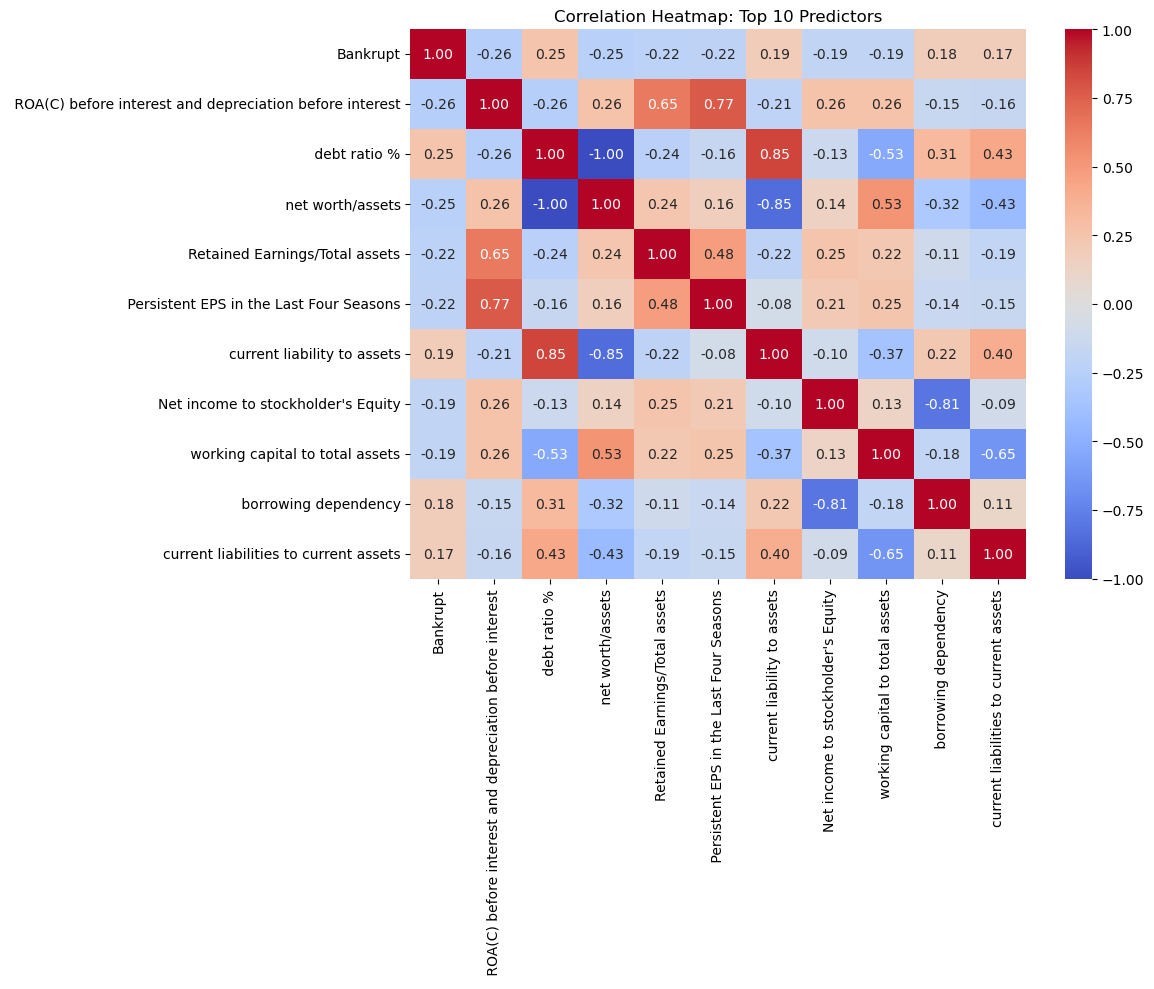

In [61]:
#Correlation Heatmap for Top Features. Select top 10 features by absolute correlation strength
top_10_features = correlations.abs().sort_values(ascending=False).index[1:11]
heatmap_cols = [target_col] + top_10_features.tolist()

plt.figure(figsize=(12, 10))
sns.heatmap(df[heatmap_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Top 10 Predictors')
plt.tight_layout()
plt.show()

C:\Users\aikat\AppData\Local\Temp\ipykernel_21320\2090037694.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df[target_col] == 0][best_feature], label='Non-Bankrupt (0)', shade=True, color='blue')
C:\Users\aikat\AppData\Local\Temp\ipykernel_21320\2090037694.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df[target_col] == 1][best_feature], label='Bankrupt (1)', shade=True, color='red')


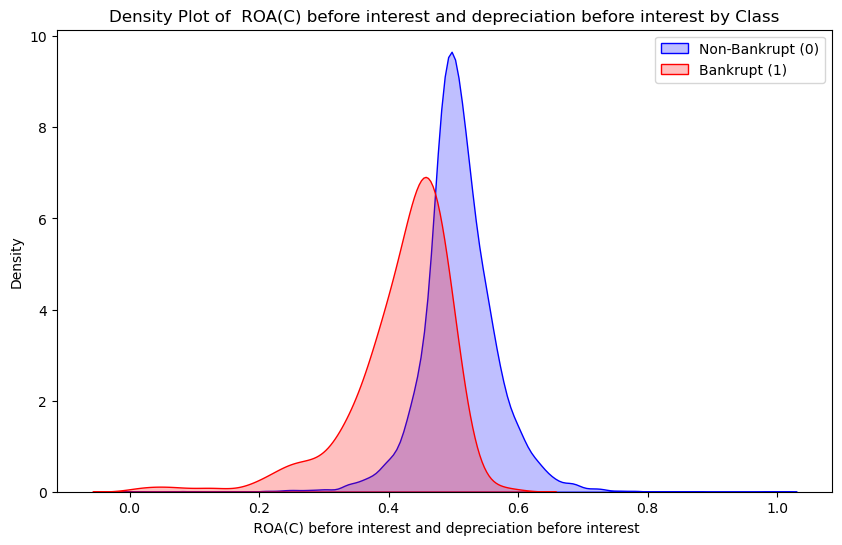

In [62]:
#Density Plots
#Print the best predictor variable VS target value
best_feature = top_10_features[0]
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df[target_col] == 0][best_feature], label='Non-Bankrupt (0)', shade=True, color='blue')
sns.kdeplot(df[df[target_col] == 1][best_feature], label='Bankrupt (1)', shade=True, color='red')
plt.title(f'Density Plot of {best_feature} by Class')
plt.xlabel(best_feature)
plt.ylabel('Density')
plt.legend()
plt.show()

'''
In the density plot, we see two curves (blue and red) showing the distribution of the best predictor for each class.

If the curves are well separated, this feature is a strong discriminator between bankrupt and non-bankrupt companies.

If the curves overlap a lot, the feature is less informative.

💡 Essentially, it’s a visual check of how well the top predictor distinguishes the two classes.
'''

'''
2️⃣ Overlap between curves

The less overlap, the stronger the feature is at separating classes.

The more overlap, the weaker it is (many non-bankrupt values look like bankrupt ones, and vice versa).

💡 Tip: You can even quantify this using KL divergence or AUC score for each feature if you want a numerical measure of separation.

3️⃣ Spread (Variance)

Narrow curves → values are concentrated → easier to classify.

Wide curves → values are spread out → harder to separate classes.
'''

In [27]:
X = df_new.drop("Bankrupt", axis=1)
y = df_new["Bankrupt"]

In [28]:
# Create and print correlation matrix
corr_matrix = X.corr()
corr_matrix

,ROA(C) before interest and depreciation before interest,operating gross margin,operating profit rate,non-industry income and expenditure/revenue,operating expense rate,research and development expense rate,cash flow rate,interest-bearing debt interest rate,tax rate (A),per Net Share Value (B),...,cash flow to equity,current liabilities to current assets,one if total liabilities exceeds total assets zero otherwise,total assets to GNP price,No-credit interval,Net income to stockholder's Equity,Degree of financial leverage (DFL),Interest coverage ratio( Interest expense to EBIT ),one if net income was negative for the last two year zero otherwise,equity to liability
ROA(C) before interest and depreciation before interest,1.000000,0.337406,0.067004,0.059010,0.065397,0.100441,0.310685,0.045375,0.253866,0.502153,...,0.099632,-0.163506,-0.121427,-0.081003,0.007365,0.264438,-0.017399,0.007264,NaN,0.047028
operating gross margin,0.337406,1.000000,0.012772,0.064532,-0.215004,-0.019742,0.353756,0.019941,0.064487,0.151533,...,0.027905,-0.163727,-0.045340,0.022998,0.002200,0.090049,-0.013857,0.003673,NaN,0.125291
operating profit rate,0.067004,0.012772,1.000000,0.486791,0.016999,0.021540,0.020248,0.004183,0.026998,0.035623,...,0.041555,-0.244663,-0.001948,-0.011247,0.000889,0.013965,0.001137,0.000645,NaN,-0.021840
non-industry income and expenditure/revenue,0.059010,0.064532,0.486791,1.000000,-0.004604,-0.007207,-0.008681,0.001258,-0.004336,0.018889,...,0.019256,-0.092056,-0.009126,-0.000541,-0.000352,0.011663,-0.000611,0.001040,NaN,0.012172
operating expense rate,0.065397,-0.215004,0.016999,-0.004604,1.000000,-0.063536,-0.019093,-0.018523,0.058423,0.098076,...,0.010674,0.017440,-0.001747,-0.027309,0.000138,0.032526,0.015333,0.005077,NaN,-0.122667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Net income to stockholder's Equity,0.264438,0.090049,0.013965,0.011663,0.032526,0.022971,0.052598,0.008759,0.072112,0.144703,...,0.151584,-0.092802,0.146344,-0.043965,-0.000587,1.000000,0.000258,0.005541,NaN,0.035016
Degree of financial leverage (DFL),-0.017399,-0.013857,0.001137,-0.000611,0.015333,-0.013180,-0.005898,-0.007028,-0.014706,-0.021667,...,-0.001875,0.021414,-0.001518,-0.001845,-0.001281,0.000258,1.000000,0.017749,NaN,-0.016732
Interest coverage ratio( Interest expense to EBIT ),0.007264,0.003673,0.000645,0.001040,0.005077,-0.021143,0.002453,-0.000256,0.022976,-0.011355,...,-0.001716,0.006578,-0.000799,0.000409,0.000564,0.005541,0.017749,1.000000,NaN,-0.007624
one if net income was negative for the last two year zero otherwise,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [30]:
# Choose the sampler:
# Option 1: oversample the minority class
sampler = RandomOverSampler(random_state=42)

# Option 2: undersample the majority class
# sampler = RandomUnderSampler(random_state=42)

# Option 3:
# sampler =SMOTE(random_state=42)

# Pipeline with over/under-sampling and SelectKBest
pipe = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('scaler', MinMaxScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('classifier', LogisticRegression())   # placeholder
])

In [31]:
# Parameter grid
param_grid = [

    # Logistic Regression
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LogisticRegression(max_iter=1000, class_weight='balanced')],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },

    # SVM
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [SVC(probability=True, class_weight='balanced')],
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },

    # Decision Tree
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [DecisionTreeClassifier(class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # Random Forest
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },

    # LightGBM (does not use class_weight, uses scale_pos_weight instead)
    {
        'feature_selection__k': [5, 10, 15],
        'classifier': [LGBMClassifier(n_estimators=100, random_state=42)],
        'classifier__max_depth': [None, 5, 10, 20],
        'classifier__num_leaves': [31, 50, 100],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__scale_pos_weight': [y.value_counts()[0] / y.value_counts()[1]]  # balance positive class
    }
]

In [34]:
# GridSearch
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',  # good for imbalanced datasets
    n_jobs=-1,
    verbose=2
)



grid.fit(X, y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [74] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,estimator,Pipeline(step...egression())])
,param_grid,"[{'classifier': [LogisticRegre...max_iter=1000)], 'classifier__C': [0.01], 'classifier__solver': ['lbfgs'], 'feature_selection__k': [5, 10]}, {'classifier': [SVC(probability=True)], 'classifier__C': [0.1], 'classifier__gamma': ['scale'], 'classifier__kernel': ['linear'], ...}, ...]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [35]:
# Evaluate
y_pred = grid.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Best Model:")
print(grid.best_estimator_)

print("\nBest Parameters:")
print(grid.best_params_)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93      1313
           1       0.23      0.92      0.37        51

    accuracy                           0.88      1364
   macro avg       0.61      0.90      0.65      1364
weighted avg       0.97      0.88      0.91      1364

Best Model:
Pipeline(steps=[('Imputer', SimpleImputer(strategy='median')),
                ('scaler', MinMaxScaler()),
                ('sampler', RandomOverSampler(random_state=42)),
                ('feature_selection', SelectKBest()),
                ('classifier',
                 RandomForestClassifier(max_depth=5, random_state=42))])

Best Parameters:
{'classifier': RandomForestClassifier(random_state=42), 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'feature_selection__k': 10}


In [37]:
#Convert CV results to DataFrame
results = pd.DataFrame(grid.cv_results_)
results['model_name'] = results['param_classifier'].apply(lambda x: type(x).__name__)

In [38]:
#Extract best configuration per model
best_per_model = (
    results
    .sort_values('mean_test_score', ascending=False)
    .groupby('model_name')
    .first()
    .reset_index()
)

In [39]:
#Refit EACH best model & Evaluate on TEST set
final_results = []
best_models_dict = {}

for _, row in best_per_model.iterrows():
    
    model_name = row['model_name']
    params = row['params']
    
    # Set best parameters
    pipe.set_params(**params)
    
    # Fit on TRAIN only
    pipe.fit(X_train, y_train)
    
    # Store trained model
    best_models_dict[model_name] = pipe
    
    # Predict on TEST
    y_pred = pipe.predict(X_test)
    
    # Store metrics
    metrics_df = model_metrics(y_test, y_pred, model_name)
    final_results.append(metrics_df)

# Combine all results
final_results_df = pd.concat(final_results, ignore_index=True)

C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [74] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [74] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[LightGBM] [Info] Number of positive: 5286, number of negative: 5286
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000783 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1261
[LightGBM] [Info] Number of data points in the train set: 10572, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [74] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [74] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\aikat\miniconda3\envs\bigblue\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid val

In [40]:
#Rank Models by Macro F1
final_results_df = final_results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

final_results_df

,Model,Accuracy,Macro F1,Macro Recall,Macro Precision,F1_Class0,Recall_Class0,Precision_Class0,F1_Class1,Recall_Class1,Precision_Class1
0,RandomForestClassifier,0.880499,0.634524,0.843697,0.601397,0.934354,0.883473,0.991453,0.334694,0.803922,0.211340
1,LGBMClassifier,0.875367,0.628369,0.841032,0.597691,0.931341,0.878142,0.991402,0.325397,0.803922,0.203980
2,DecisionTreeClassifier,0.864370,0.613388,0.825896,0.588675,0.924888,0.867479,0.990435,0.301887,0.784314,0.186916
3,LogisticRegression,0.844575,0.605313,0.862730,0.586946,0.912613,0.843107,0.994609,0.298013,0.882353,0.179283
4,SVC,0.837243,0.598287,0.858922,0.583487,0.908113,0.835491,0.994560,0.288462,0.882353,0.172414


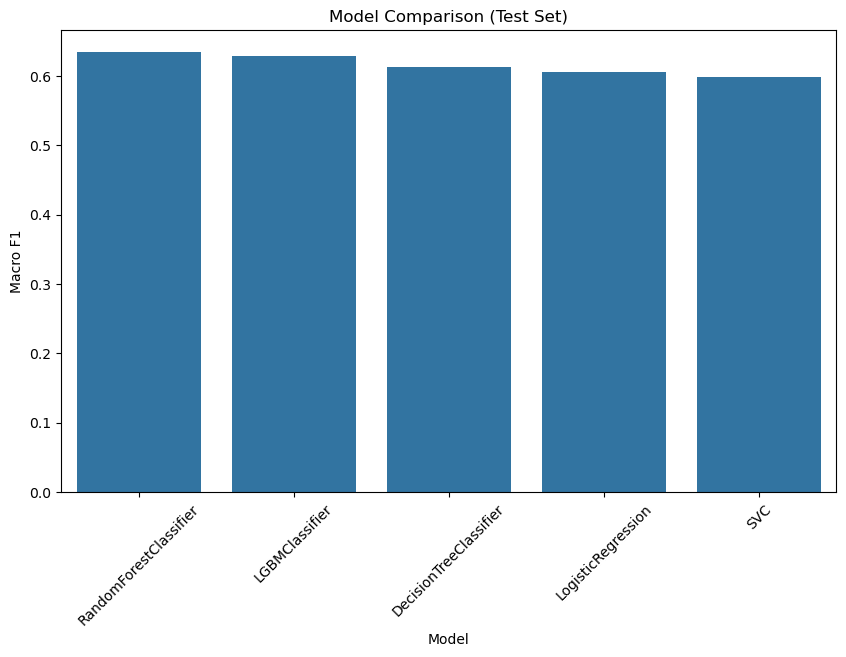

In [41]:
#Optional: Plot Model Comparison
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    data=final_results_df,
    x="Model",
    y="Macro F1"
)

plt.title("Model Comparison (Test Set)")
plt.xticks(rotation=45)
plt.show()

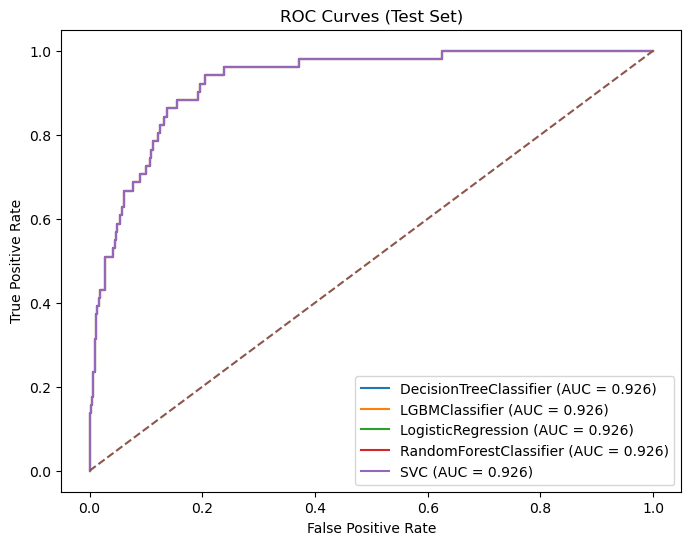

In [42]:
#PLot ROC curves
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

roc_auc_scores = {}

for model_name, model in best_models_dict.items():
    
    # Some models use predict_proba, others decision_function
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        y_scores = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    
    roc_auc_scores[model_name] = roc_auc
    
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Test Set)")
plt.legend()
plt.show()

In [63]:
for model_name, model in best_models_dict.items():
    if hasattr(model, "predict_proba"):
        print(model_name, np.min(model.predict_proba(X_test)[:,1]), np.max(model.predict_proba(X_test)[:,1]))
    else:
        print(model_name, np.min(model.decision_function(X_test)), np.max(model.decision_function(X_test)))

DecisionTreeClassifier 8.509047076488032e-06 0.9999999993836318
LGBMClassifier 8.509047076488032e-06 0.9999999993836318
LogisticRegression 8.509047076488032e-06 0.9999999993836318
RandomForestClassifier 8.509047076488032e-06 0.9999999993836318
SVC 8.509047076488032e-06 0.9999999993836318


In [43]:
#AUC Summary Table
auc_df = pd.DataFrame(
    roc_auc_scores.items(),
    columns=["Model", "AUC"]
).sort_values("AUC", ascending=False)

auc_df

,Model,AUC
0,DecisionTreeClassifier,0.925974
1,LGBMClassifier,0.925974
2,LogisticRegression,0.925974
3,RandomForestClassifier,0.925974
4,SVC,0.925974


In [51]:
#Merge CV Results + Test Results + AUC
final_report = final_results_df.merge(
    auc_df,
    on="Model",
    how="left"
)

final_report = final_report.sort_values(
    by=["Macro F1", "AUC"],
    ascending=False
).reset_index(drop=True)

final_report

,Model,Accuracy,Macro F1,Macro Recall,Macro Precision,F1_Class0,Recall_Class0,Precision_Class0,F1_Class1,Recall_Class1,Precision_Class1,AUC
0,RandomForestClassifier,0.880499,0.634524,0.843697,0.601397,0.934354,0.883473,0.991453,0.334694,0.803922,0.211340,0.925974
1,LGBMClassifier,0.875367,0.628369,0.841032,0.597691,0.931341,0.878142,0.991402,0.325397,0.803922,0.203980,0.925974
2,DecisionTreeClassifier,0.864370,0.613388,0.825896,0.588675,0.924888,0.867479,0.990435,0.301887,0.784314,0.186916,0.925974
3,LogisticRegression,0.844575,0.605313,0.862730,0.586946,0.912613,0.843107,0.994609,0.298013,0.882353,0.179283,0.925974
4,SVC,0.837243,0.598287,0.858922,0.583487,0.908113,0.835491,0.994560,0.288462,0.882353,0.172414,0.925974


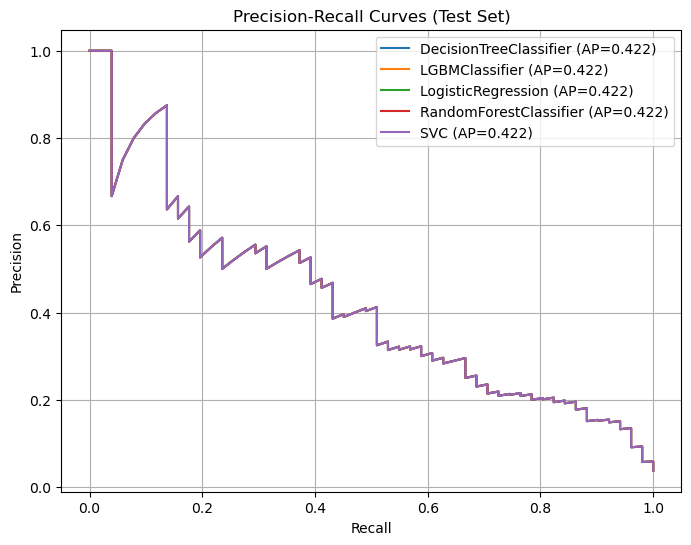

In [52]:
#Compute PR curves for all models
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
pr_scores = {}

for model_name, model in best_models_dict.items():
    
    # Get predicted probabilities or decision scores
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)[:, 1]
    else:
        # decision_function for SVM
        y_scores = model.decision_function(X_test)
    
    precision, recall, _ = precision_recall_curve(y_test, y_scores)
    avg_precision = average_precision_score(y_test, y_scores)
    
    pr_scores[model_name] = avg_precision
    
    plt.plot(recall, precision, label=f"{model_name} (AP={avg_precision:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
pr_df = pd.DataFrame(
    pr_scores.items(),
    columns=["Model", "Average Precision (AP)"]
).sort_values("Average Precision (AP)", ascending=False)

pr_df

,Model,Average Precision (AP)
0,DecisionTreeClassifier,0.422499
1,LGBMClassifier,0.422499
2,LogisticRegression,0.422499
3,RandomForestClassifier,0.422499
4,SVC,0.422499


In [64]:
#SHAP Values for best model
best_model_name = final_results_df.iloc[0]["Model"]
best_model = best_models_dict[best_model_name]

In [69]:
best_model_name

'RandomForestClassifier'

In [66]:
# Extract fitted steps from pipeline
imputer = best_model.named_steps["Imputer"]           # fitted
scaler = best_model.named_steps["scaler"]             # fitted
selector = best_model.named_steps["feature_selection"]# fitted
classifier = best_model.named_steps["classifier"]     # fitted

# Transform the test data using the fitted pipeline steps
X_test_imputed = imputer.transform(X_test)
X_test_scaled = scaler.transform(X_test_imputed)
X_test_transformed = selector.transform(X_test_scaled)

In [71]:
#Compute SHAP
import shap

tree_models = (RandomForestClassifier, DecisionTreeClassifier, LGBMClassifier)

if isinstance(classifier, tree_models):
    explainer = shap.TreeExplainer(classifier)
else:
    explainer = shap.Explainer(classifier, X_test_transformed)

shap_values = explainer(X_test_transformed)

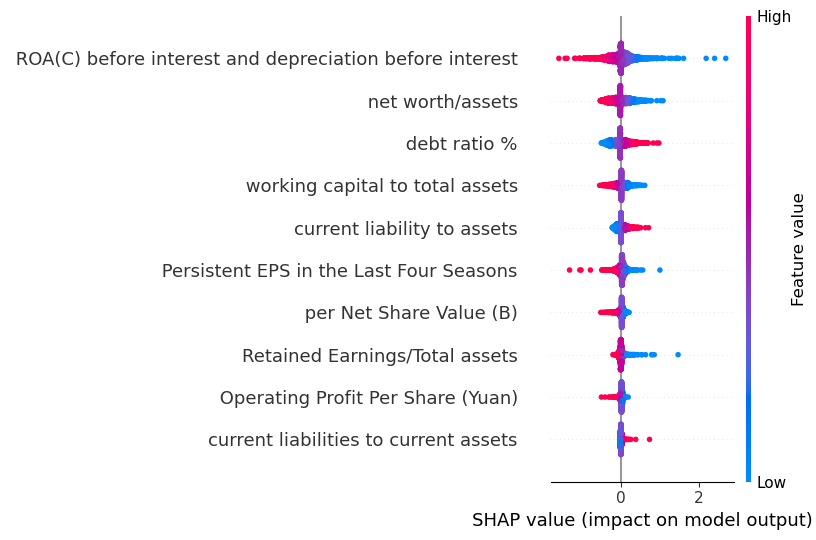

In [74]:
#Plot SHAP Summary
# 1️⃣ Original column names before any preprocessing
original_feature_names = X_test.columns.tolist()

# 2️⃣ Get the mask from your fitted selector
mask = selector.get_support()  # boolean array

# 3️⃣ Apply mask to get selected feature names
selected_feature_names = [f for f, m in zip(original_feature_names, mask) if m]

shap.summary_plot(shap_values, X_test_transformed, feature_names=selected_feature_names)